In [165]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import os, re, sys
%matplotlib inline
## 设置属性防止中文乱码
plt.rcParams['font.sans-serif'] = [u'SimHei']
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings("ignore")

In [166]:
import matplotlib as mpl
print('pandas:%s'%(pd.__version__))
print('numpy:%s'%(np.__version__))
print('matplotlib:%s'%(mpl.__version__))
print('seaborn:%s'%(sns.__version__))

pandas:2.0.0
numpy:1.23.5
matplotlib:3.7.1
seaborn:0.12.2


## 0.读取数据

In [167]:
df = pd.read_excel('lift_score_sample.xlsx')
df.shape

(10000, 2)

In [168]:
df.target.value_counts()

target
0    9500
1     500
Name: count, dtype: int64

## 1.Lift提升度计算

In [169]:
# 等频分箱
n = 10
df_bin=pd.qcut(df['xgb_score'],n)
group_all=df['target'].groupby(df_bin).count()
group_bad=df['target'].groupby(df_bin).sum()
group_good=group_all-group_bad    
var_bin=pd.DataFrame()
var_bin['sum']=group_all
var_bin['bad_count']=group_bad
var_bin['good_count']=group_good

# 第一种Lift计算方式
var_bin['badpct']=var_bin['bad_count']/var_bin['bad_count'].sum()
var_bin['allpct']=var_bin['sum']/var_bin['sum'].sum()
var_bin['cum_badpct'] = var_bin['badpct'].cumsum()
var_bin['cum_allpct'] = var_bin['allpct'].cumsum()
var_bin['cum_lift'] = var_bin['cum_badpct']/var_bin['cum_allpct']

# 第二种Lift计算方式
var_bin['badrate'] = var_bin['bad_count']/var_bin['sum']
var_bin['lift'] = var_bin['badrate']/df['target'].mean()

In [170]:
var_bin

,sum,bad_count,good_count,badpct,allpct,cum_badpct,cum_allpct,cum_lift,badrate,lift
xgb_score,,,,,,,,,,
"(205.38899999999998, 448.898]",1000,150,850,0.30,0.1000,0.30,0.1000,3.000000,0.150000,3.000000
"(448.898, 483.828]",1000,100,900,0.20,0.1000,0.50,0.2000,2.500000,0.100000,2.000000
"(483.828, 508.842]",1000,70,930,0.14,0.1000,0.64,0.3000,2.133333,0.070000,1.400000
"(508.842, 530.35]",1001,50,951,0.10,0.1001,0.74,0.4001,1.849538,0.049950,0.999001
"(530.35, 550.93]",1001,45,956,0.09,0.1001,0.83,0.5002,1.659336,0.044955,0.899101
"(550.93, 570.996]",998,35,963,0.07,0.0998,0.90,0.6000,1.500000,0.035070,0.701403
"(570.996, 592.425]",1000,20,980,0.04,0.1000,0.94,0.7000,1.342857,0.020000,0.400000
"(592.425, 618.716]",1000,15,985,0.03,0.1000,0.97,0.8000,1.212500,0.015000,0.300000
"(618.716, 654.116]",1000,10,990,0.02,0.1000,0.99,0.9000,1.100000,0.010000,0.200000


## 2.Lift-chart可视化

In [171]:
########################## PlotLift #############################   
def PlotLift(preds, labels, n, asc):
    """
    liftchart可视化（方式二）
    
    @param preds: 模型预测列
    @param labels: 好坏的y标签
    @param n: 分箱数
    @param asc: 是否升序，值为0或1；asc=1时preds是分数，asc=0时preds是概率
    """
    
    pred = preds  # 预测值
    bad = labels  # 取1为bad, 0为good
    lftds = pd.DataFrame({'bad': bad, 'pred': pred})
    lftds['good'] = 1 - lftds.bad
    
    if asc == 1:
        lftds1 = lftds.sort_values(by=['pred', 'bad'], ascending=[True, True])
    elif asc == 0:
        lftds1 = lftds.sort_values(by=['pred', 'bad'], ascending=[False, True])
    
    lftds1.index = range(len(lftds1.pred))
    
    qe = list(np.arange(0, 1, 1.0/n))
    qe.append(1)
    qe = qe[1:]
    
    lft_index = pd.Series(lftds1.index)
    lft_index = lft_index.quantile(q = qe)
    lft_index = np.ceil(lft_index).astype(int)
    lft_index = list(lft_index)
    
    Rate_all = 1.0*sum(lftds1.bad)/len(lftds1.bad)
    
    lift = []
    temp = lftds1.loc[lftds1.index<=lft_index[0]]
    lift = lift + [1.0*sum(temp.bad)/len(temp.bad)/Rate_all]
    
    for i in range(1, len(lft_index)):
        temp = lftds1.loc[(lftds1.index<=lft_index[i]) & (lftds1.index>lft_index[i-1])]
        lift = lift + [1.0*sum(temp.bad)/len(temp.bad)/Rate_all]
    
    lift_no = range(1, len(lift)+1)
    
    fig = plt.figure(dpi=150)
    plt.plot(lift_no, lift, 'ro-', linewidth=2)
    plt.axhline(1, color='gray', linestyle='--')
    plt.title('Lift-chart', fontsize=15)

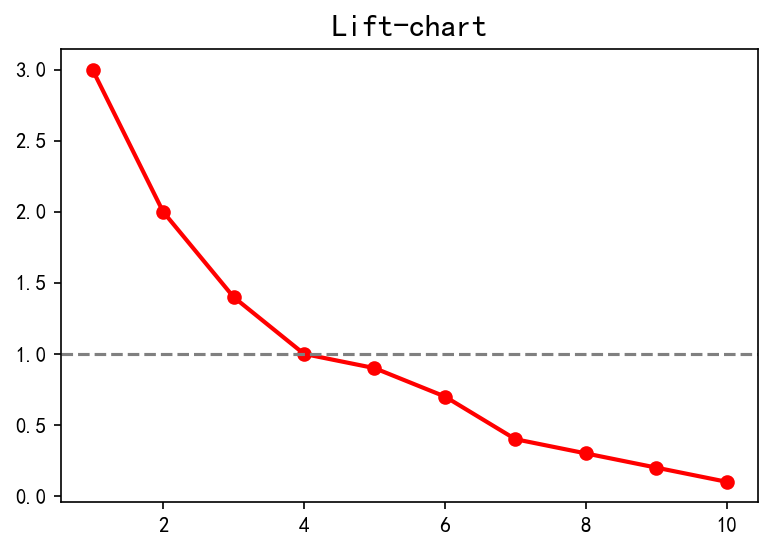

In [172]:
# 分10箱
PlotLift(df['xgb_score'],df['target'],10,asc=1)

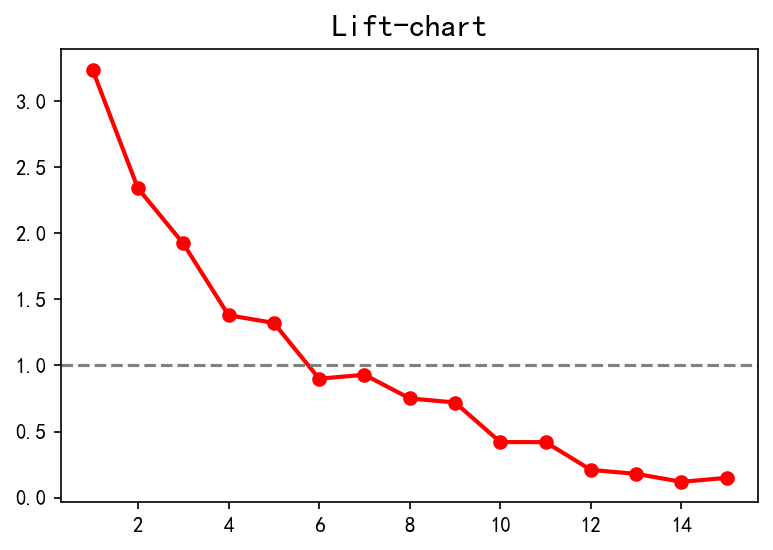

In [173]:
# 分15箱
PlotLift(df['xgb_score'],df['target'],15,asc=1)

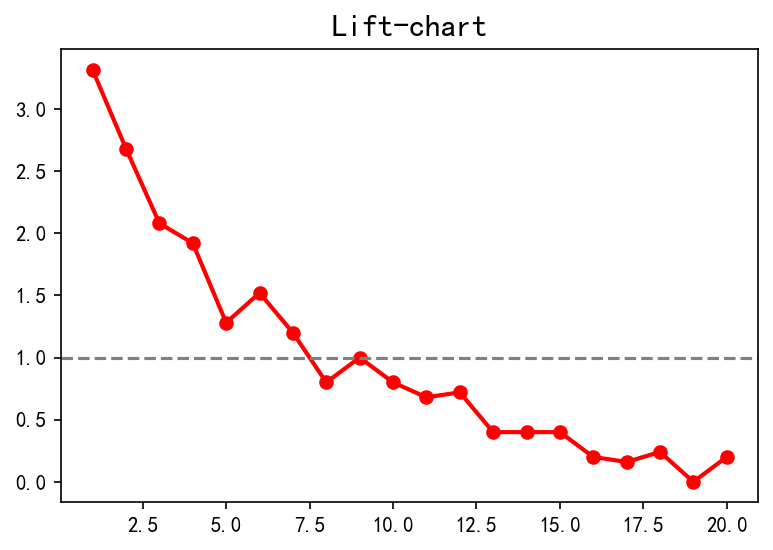

In [174]:
# 分20箱
PlotLift(df['xgb_score'],df['target'],20,asc=1)

# Lift 提升度指标

计算模型或规则提升度并绘制 Lift Chart 的 Python 实现。

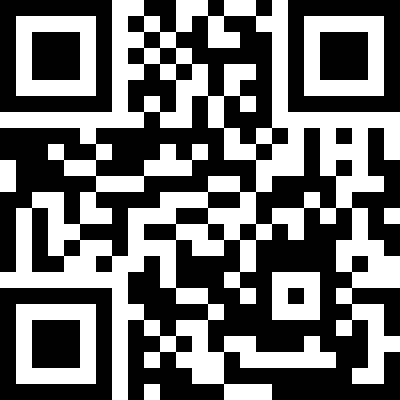